# AI-ML Assignment - 3

# Salary Prediction using Polynomial Regression

---

## Submitted By

**Name:** Abhishek Thakur

**Registration Number:** 23MIM10078

**Application Number:** IN26011189

**Batch:** 1A

---

## Course

Artificial Intelligence and Machine Learning

---

## Objective

To develop a Polynomial Regression model that predicts employee salaries based on their position level and evaluate its performance using appropriate regression metrics.

# Import Required Libraries

The following libraries are imported for data manipulation, visualization, model building, preprocessing, and evaluation.

In [ ]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Generate polynomial features
from sklearn.preprocessing import PolynomialFeatures

# Linear Regression model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display plots within the notebook
%matplotlib inline

# Task 1: Data Understanding

### Objective
The objective of this task is to understand the dataset by loading it, exploring its structure, identifying the input feature and target variable, and examining its statistical properties.

In [ ]:
# ============================================================
# Task 1 : Data Understanding
# ============================================================

# Import the Pandas library
import pandas as pd

# ------------------------------------------------------------
# Step 1: Load the dataset
# ------------------------------------------------------------

print("=" * 60)
print("Loading the Position Salaries Dataset...")
print("=" * 60)

df = pd.read_csv("data/Position_Salaries.csv")

print("✅ Dataset loaded successfully.\n")


# ------------------------------------------------------------
# Step 2: Display the first five records
# ------------------------------------------------------------

print("=" * 60)
print("First Five Records of the Dataset")
print("=" * 60)

display(df.head())


# ------------------------------------------------------------
# Step 3: Display dataset dimensions
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Dataset Shape")
print("=" * 60)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")


# ------------------------------------------------------------
# Step 4: Identify Input Feature and Target Variable
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Input Feature and Target Variable")
print("=" * 60)

input_feature = df.columns[1]
target_variable = df.columns[2]

print(f"Input Feature (X)  : {input_feature}")
print(f"Target Variable (y): {target_variable}")


# ------------------------------------------------------------
# Step 5: Display column names
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Column Names")
print("=" * 60)

print(df.columns.tolist())


# ------------------------------------------------------------
# Step 6: Display dataset information
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()


# ------------------------------------------------------------
# Step 7: Display summary statistics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Summary Statistics")
print("=" * 60)

display(df.describe())


# ------------------------------------------------------------
# Task 1 Completed
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("✅ Task 1 Completed Successfully")
print("=" * 60)

Loading the Position Salaries Dataset...
✅ Dataset loaded successfully.

First Five Records of the Dataset


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000



Dataset Shape
Number of Rows    : 10
Number of Columns : 3

Input Feature and Target Variable
Input Feature (X)  : Level
Target Variable (y): Salary

Column Names
['Position', 'Level', 'Salary']

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes

Summary Statistics


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000



✅ Task 1 Completed Successfully


# Task 2: Data Preprocessing

### Objective
The objective of this task is to preprocess the dataset by checking for missing values, selecting the input feature and target variable, and splitting the dataset into training and testing sets.

In [ ]:
# ============================================================
# Task 2 : Data Preprocessing
# ============================================================

# Import the required library
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Step 1: Check for missing values
# ------------------------------------------------------------

print("=" * 60)
print("Checking for Missing Values")
print("=" * 60)

print(df.isnull().sum())


# ------------------------------------------------------------
# Step 2: Select the input feature and target variable
# ------------------------------------------------------------

X = df[['Level']]
y = df['Salary']

print("\nInput Feature (X): Level")
print("Target Variable (y): Salary")


# ------------------------------------------------------------
# Step 3: Split the dataset into training and testing sets
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nDataset Split (80% Training : 20% Testing)")
print("-" * 60)

print(f"Training Feature Shape : {X_train.shape}")
print(f"Testing Feature Shape  : {X_test.shape}")
print(f"Training Target Shape  : {y_train.shape}")
print(f"Testing Target Shape   : {y_test.shape}")


# ------------------------------------------------------------
# Task 2 Completed
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("✅ Task 2 Completed Successfully")
print("=" * 60)

Checking for Missing Values
Position    0
Level       0
Salary      0
dtype: int64

Input Feature (X): Level
Target Variable (y): Salary

Dataset Split (80% Training : 20% Testing)
------------------------------------------------------------
Training Feature Shape : (8, 1)
Testing Feature Shape  : (2, 1)
Training Target Shape  : (8,)
Testing Target Shape   : (2,)

✅ Task 2 Completed Successfully


# Task 3: Model Development

### Objective
The objective of this task is to transform the input feature using Polynomial Features (Degree = 3), train a Polynomial Regression model, and predict salaries for the test dataset.

In [ ]:
# ============================================================
# Task 3 : Model Development
# ============================================================

# Import required libraries
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# ------------------------------------------------------------
# Step 1: Transform the input feature using Polynomial Features
# ------------------------------------------------------------

poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("=" * 60)
print("Polynomial Feature Transformation Completed")
print("=" * 60)


# ------------------------------------------------------------
# Step 2: Train the Polynomial Regression Model
# ------------------------------------------------------------

model = LinearRegression()

model.fit(X_train_poly, y_train)

print("\nPolynomial Regression Model Trained Successfully")


# ------------------------------------------------------------
# Step 3: Predict salaries for the test dataset
# ------------------------------------------------------------

y_pred = model.predict(X_test_poly)

print("\nPredicted Salaries for Test Dataset")
print("-" * 60)

print(y_pred)


# ------------------------------------------------------------
# Task 3 Completed
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("✅ Task 3 Completed Successfully")
print("=" * 60)

Polynomial Feature Transformation Completed

Polynomial Regression Model Trained Successfully

Predicted Salaries for Test Dataset
------------------------------------------------------------
[606335.60051157  84934.89129171]

✅ Task 3 Completed Successfully


# Task 4: Model Evaluation

### Objective
The objective of this task is to evaluate the performance of the Polynomial Regression model using regression metrics and visualize the fitted polynomial regression curve.

Model Evaluation Metrics
Mean Absolute Error (MAE) : 70635.25
Mean Squared Error (MSE)  : 6263853282.86
R² Score                  : 0.8763


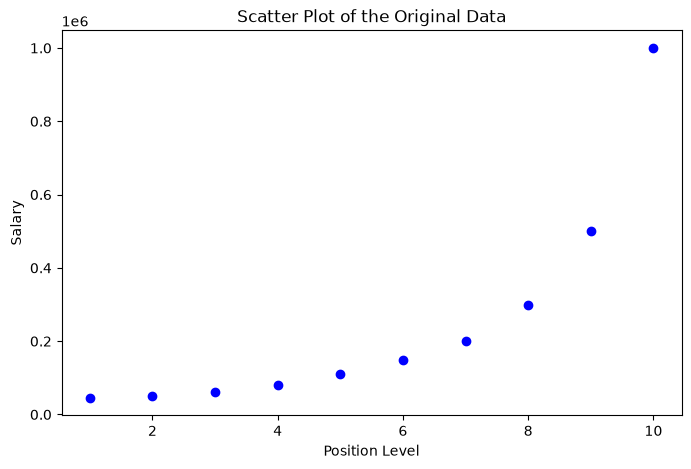

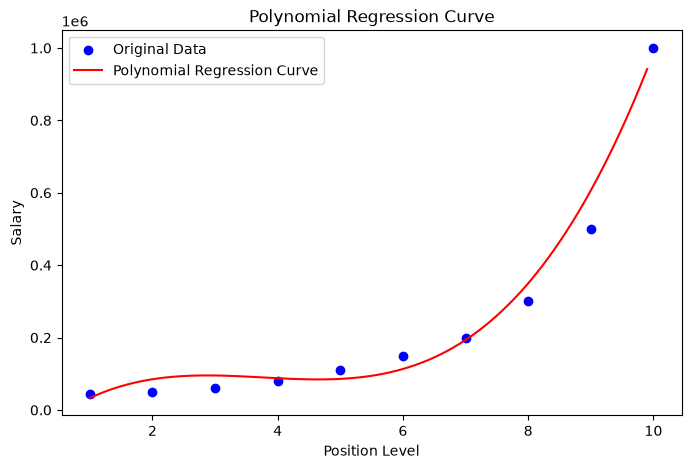

✅ Task 4 Completed Successfully


In [ ]:
# ============================================================
# Task 4 : Model Evaluation
# ============================================================

# ------------------------------------------------------------
# Step 1: Calculate Evaluation Metrics
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("Model Evaluation Metrics")
print("=" * 60)

print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Mean Squared Error (MSE)  : {mse:.2f}")
print(f"R² Score                  : {r2:.4f}")

# ------------------------------------------------------------
# Step 2: Scatter Plot of the Original Data
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(X["Level"], y, color="blue")

plt.title("Scatter Plot of the Original Data")
plt.xlabel("Position Level")
plt.ylabel("Salary")

plt.show()

# ------------------------------------------------------------
# Step 3: Polynomial Regression Curve
# ------------------------------------------------------------

# Create a smooth range of values
X_grid = pd.DataFrame(
    np.arange(X["Level"].min(), X["Level"].max(), 0.1),
    columns=["Level"]
)

# Plot original data
plt.figure(figsize=(8, 5))
plt.scatter(X["Level"], y, color="blue", label="Original Data")

# Plot polynomial regression curve
plt.plot(
    X_grid["Level"],
    model.predict(poly.transform(X_grid)),
    color="red",
    label="Polynomial Regression Curve"
)

plt.title("Polynomial Regression Curve")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()

plt.show()

# ------------------------------------------------------------
# Task 4 Completed
# ------------------------------------------------------------

print("=" * 60)
print("✅ Task 4 Completed Successfully")
print("=" * 60)

## Observations

1. The Polynomial Regression model effectively captures the nonlinear relationship between position level and salary, achieving an R² score of **0.8763**.

2. The Mean Absolute Error (MAE) of **70635.25** indicates that the predicted salaries are reasonably close to the actual salaries.

3. The Polynomial Regression curve fits the original data well, demonstrating that a degree-3 polynomial is suitable for this dataset.

# Task 5: Conclusion

### Objective
The objective of this task is to summarize the overall performance and effectiveness of the Polynomial Regression model developed for salary prediction.

## Conclusion

The Polynomial Regression model was successfully developed to predict employee salaries based on their position level. The dataset was preprocessed, transformed using Polynomial Features with degree 3, and divided into training and testing sets using an 80:20 ratio. The model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score. The obtained R² Score of **0.8763** indicates that the model explains a significant portion of the variance in salary values, demonstrating good predictive performance. The Polynomial Regression curve closely follows the nonlinear trend of the dataset, making it more suitable than a simple linear model for this problem. Overall, Polynomial Regression proved to be an effective approach for modeling the relationship between employee position level and salary.